### Khang Tran Homework 02 Regression

In [45]:
import pandas as pd
import numpy as np

url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
df = pd.read_csv(url)
df = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
feature = ['engine_displacement','horsepower','vehicle_weight','model_year']
target = ['fuel_efficiency_mpg']
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

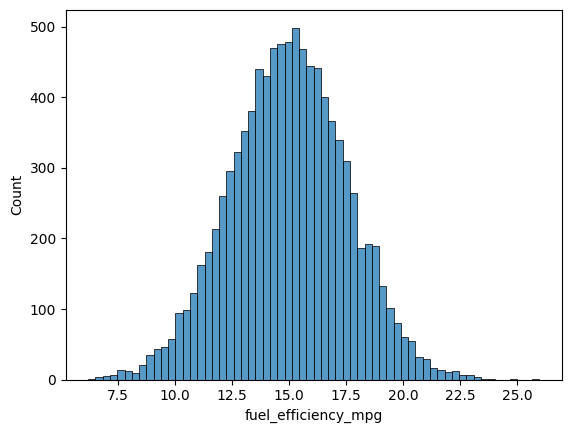

In [46]:
import seaborn as sns
sns.histplot(x='fuel_efficiency_mpg', data=df)

### Q1. Columns have missing values:

In [47]:
col_missing = []
for i in df.columns:
    if df[i].isnull().sum() > 0:
        col_missing.append(i)
print('Column have missing values:',col_missing)

Column have missing values: ['horsepower']


### Q2. Median for *horsepower*:

In [48]:
print('Median for horsepower:',df['horsepower'].median())

Median for horsepower: 149.0


#### Prepare and split the dataset (same code in lecture)

In [49]:
### Train / val / test distribution:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n_train, n_val, n_test

(5824, 1940, 1940)

In [50]:
### Random dataset
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

### Subset dataframe
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

### Check number of rows
assert (len(df_train), len(df_val), len(df_test)) == (n_train, n_val, n_test)

In [51]:
### Fill with 0:
train_fill_0 = df_train.fillna(0)
val_fill_0 = df_val.fillna(0)

### Fill with mean:
train_fill_mean = df_train.fillna(df['horsepower'].mean())
val_fill_mean = df_val.fillna(df['horsepower'].mean())

### Q3. RMSE baseline Linear Regression without Regularization:

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 2 decimal digits using `round(score, 2)`
* Which option gives better RMSE?

In [52]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0], dtype = int)
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

val_fill_0

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6163,180,112.0,2772.134410,2020,15.366341
3313,260,138.0,3014.061530,2022,14.601182
4781,140,181.0,3652.186151,2016,12.247032
8210,270,105.0,2753.040847,2023,15.136400
6713,170,224.0,4163.375137,2003,10.340419
...,...,...,...,...,...
7802,290,205.0,3403.401496,2019,13.868607
6780,200,159.0,2752.516039,2009,15.665403
7541,230,202.0,3303.000688,2008,13.613127
1577,220,169.0,3293.420251,2008,13.733343


In [64]:
### For fill with 0
X_train_fill_0 = train_fill_0[feature].values
y_train_fill_0 = train_fill_0['fuel_efficiency_mpg'].values
w_0_0, w_0 = train_linear_regression(X_train_fill_0, y_train_fill_0)

y_pred_fill_0 = w_0_0 + val_fill_0[feature].values.dot(w_0)
rmse_fill_0 = rmse(y_val, y_pred_fill_0)
rmse_fill_0 = float(round(rmse_fill_0,5))

In [ ]:
### For fill with mean:
X_train_fill_mean = train_fill_mean[['engine_displacement','horsepower','vehicle_weight','model_year']].values
y_train_fill_mean = train_fill_mean['fuel_efficiency_mpg'].values
w_0_mean, w_mean = train_linear_regression(X_train_fill_mean, y_train_fill_mean)

y_pred_fill_mean = w_0_mean + val_fill_mean[feature].values.dot(w_mean)
rmse_fill_mean = rmse(y_val, y_pred_fill_mean)
rmse_fill_mean = float(round(rmse_fill_mean,5))

In [63]:
if rmse_fill_0 < rmse_fill_mean:
    print('Filling missing values with 0 is better. RMSE:')
    print(rmse_fill_0)
elif rmse_fill_mean == rmse_fill_0:
    print('Both are equally good. RMSE:')
    print(rmse_fill_0)
else:
    print('Filling missing values with MEAN is better. RMSE:')
    print(rmse_fill_mean)   

Filling missing values with MEAN is better. RMSE:
3.59582


### Q4. r give the best RMSE with Regularized Linear Regression:

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 2 decimal digits.
* Which `r` gives the best RMSE?

In [68]:
val_fill_0

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6163,180,112.0,2772.134410,2020,15.366341
3313,260,138.0,3014.061530,2022,14.601182
4781,140,181.0,3652.186151,2016,12.247032
8210,270,105.0,2753.040847,2023,15.136400
6713,170,224.0,4163.375137,2003,10.340419
...,...,...,...,...,...
7802,290,205.0,3403.401496,2019,13.868607
6780,200,159.0,2752.516039,2009,15.665403
7541,230,202.0,3303.000688,2008,13.613127
1577,220,169.0,3293.420251,2008,13.733343


In [70]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

r_list = [0, 0.01,1,10, 100]
rmse_r_dict = {}
for r in r_list:
    w_0_r, w_r = train_linear_regression_reg(X_train_fill_0, y_train_fill_0, r)
    y_pred_r = w_0_r + val_fill_0[feature].values.dot(w_r)
    rmse_r = float(round(rmse(val_fill_0[target].values, y_pred_r),4))
    rmse_r_dict[r] = rmse_r

rmse_r_dict

{0: 3.7136, 0.01: 3.7133, 1: 3.7124, 10: 3.7124, 100: 3.7124}

### Q5. Value of std of RMSE between seeds:

In [57]:
seeds = list(range(10))
rmse_scores = []
for seed in seeds:
    idx = np.arange(len(df))
    np.random.seed(seed)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]

    train_fill_0 = df_train.fillna(0)

    X_val = df_val[['engine_displacement','horsepower','vehicle_weight','model_year']].fillna(0).values
    y_val = df_val['fuel_efficiency_mpg'].values

    X_train_fill_0 = train_fill_0[['engine_displacement','horsepower','vehicle_weight','model_year']].values
    y_train_fill_0 = train_fill_0['fuel_efficiency_mpg'].values
    w_0_0, w_0 = train_linear_regression(X_train_fill_0, y_train_fill_0)

    y_pred_fill_0 = w_0_0 + X_val.dot(w_0)
    rmse_fill_0 = rmse(y_val, y_pred_fill_0)
    rmse_fill_0 = float(round(rmse_fill_0,6))
    print(f'Seed: {seed}, RMSE: {rmse_fill_0}')
    rmse_scores.append(rmse_fill_0)
print()
print('RMSE scores for all seeds:',rmse_scores)
print('Std of RMSE between different seeds:',round(np.std(rmse_scores),3))


Seed: 0, RMSE: 0.520653
Seed: 1, RMSE: 0.521339
Seed: 2, RMSE: 0.522807
Seed: 3, RMSE: 0.515952
Seed: 4, RMSE: 0.510913
Seed: 5, RMSE: 0.528341
Seed: 6, RMSE: 0.531391
Seed: 7, RMSE: 0.509067
Seed: 8, RMSE: 0.51474
Seed: 9, RMSE: 0.513187

RMSE scores for all seeds: [0.520653, 0.521339, 0.522807, 0.515952, 0.510913, 0.528341, 0.531391, 0.509067, 0.51474, 0.513187]
Std of RMSE between different seeds: 0.007


### Q6. Best RMSE on test dataset:

In [58]:
idx = np.arange(len(df))
np.random.seed(9)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_trainval = pd.concat([df_train, df_val], ignore_index=True)
df_trainval = df_trainval.fillna(0)

X_trainval = df_trainval[['engine_displacement','horsepower','vehicle_weight','model_year']].values
y_trainval = df_trainval['fuel_efficiency_mpg'].values

X_test = df_test[['engine_displacement','horsepower','vehicle_weight','model_year']].fillna(0).values
y_test = df_test['fuel_efficiency_mpg'].values

w_0_final, w_final = train_linear_regression_reg(X_trainval, y_trainval,r=0.001)
y_pred_test = w_0_final + X_test.dot(w_final)
rmse_test = float(round(rmse(y_test, y_pred_test),3))
rmse_test


0.516